<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/RNN/Simple_Recurrent_Neural_Network_(RNN)_for_NLP_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Natural Language Processing (NLP)
O Processamento de Linguagem Natural (PNL), ou NLP (Natural Language Processing) em inglês, é uma área da inteligência artificial que se dedica a permitir que os algoritmos compreendam, interpretem e gerem a linguagem humana. É um campo interdisciplinar que combina ciência da computação, linguística e inteligência artificial.

###O que o NLP faz?
O NLP permite que os computadores processem e analisem texto e fala, extraindo informações como significado, sentimento e intenção por trás das palavras. Isso possibilita diversas aplicações, como:
- Tradução automática: Traduzir textos de um idioma para outro.
Análise de sentimento: Determinar a emoção expressa em um texto (positivo, negativo, neutro).
- Resumo automático de texto: Gerar resumos concisos de textos longos.
- Chatbots: Criar sistemas de conversação automatizados para interagir com usuários.
- Classificação de texto: Categorizar documentos de acordo com seu conteúdo.
- Extração de informações: Identificar entidades e relacionamentos em textos.
- Geração de texto: Criar textos de forma automática com base em prompts ou modelos.

###Como o NLP funciona?
O NLP utiliza diversas técnicas, incluindo:
- Linguística computacional:
Estuda a linguagem humana do ponto de vista da computação, criando modelos e regras para a análise e geração de texto.
- Aprendizado de máquina:
Permite que os computadores aprendam com grandes volumes de dados para melhorar seu desempenho em tarefas de NLP.
- Aprendizado profundo (Deep Learning):
Utiliza redes neurais profundas para modelar a linguagem de forma mais complexa e eficaz.

###Aplicações do NLP:
O NLP tem aplicações em diversas áreas, como:
- Atendimento ao cliente: Chatbots e sistemas de análise de sentimento para melhorar o suporte ao cliente.
- Marketing e publicidade: Análise de sentimentos para entender a percepção da marca e personalizar campanhas.
- Saúde: Análise de prontuários médicos e identificação de padrões em dados de pacientes.
- Finanças: Detecção de fraudes e análise de risco.
- Educação: Ferramentas de aprendizado e avaliação automatizadas.

In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
import matplotlib.pyplot as plt

In [33]:
text = "Texto para se testar o Processamento de Linguagem Natural (NLP)"
chars = sorted(set(text))
char_to_index = {char: i for i, char in enumerate(chars)}
index_to_char = {i: char for i, char in enumerate(chars)}

In [34]:
len(text)

63

In [35]:
len(chars)

23

In [36]:
chars

[' ',
 '(',
 ')',
 'L',
 'N',
 'P',
 'T',
 'a',
 'c',
 'd',
 'e',
 'g',
 'i',
 'l',
 'm',
 'n',
 'o',
 'p',
 'r',
 's',
 't',
 'u',
 'x']

In [37]:
char_to_index

{' ': 0,
 '(': 1,
 ')': 2,
 'L': 3,
 'N': 4,
 'P': 5,
 'T': 6,
 'a': 7,
 'c': 8,
 'd': 9,
 'e': 10,
 'g': 11,
 'i': 12,
 'l': 13,
 'm': 14,
 'n': 15,
 'o': 16,
 'p': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'x': 22}

In [38]:
index_to_char

{0: ' ',
 1: '(',
 2: ')',
 3: 'L',
 4: 'N',
 5: 'P',
 6: 'T',
 7: 'a',
 8: 'c',
 9: 'd',
 10: 'e',
 11: 'g',
 12: 'i',
 13: 'l',
 14: 'm',
 15: 'n',
 16: 'o',
 17: 'p',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'x'}

In [39]:
seq_length = 3
sequences = []
labels = []

for i in range(len(text) - seq_length):
	seq = text[i:i+seq_length]
	label = text[i+seq_length]
	sequences.append([char_to_index[char] for char in seq])
	labels.append(char_to_index[label])

In [40]:
len(sequences)

60

In [41]:
sequences[0:6]

[[6, 10, 22], [10, 22, 20], [22, 20, 16], [20, 16, 0], [16, 0, 17], [0, 17, 7]]

In [42]:
len(labels)

60

In [43]:
labels[0:10]

[20, 16, 0, 17, 7, 18, 7, 0, 19, 10]

In [44]:
X = np.array(sequences)
y = np.array(labels)

X_one_hot = tf.one_hot(X, len(chars))
y_one_hot = tf.one_hot(y, len(chars))

In [45]:
len(X_one_hot)

60

In [46]:
X_one_hot[0]

<tf.Tensor: shape=(3, 23), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1.]], dtype=float32)>

In [47]:
len(y_one_hot)

60

In [48]:
y_one_hot[0]

<tf.Tensor: shape=(23,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0.], dtype=float32)>

In [49]:
model = Sequential()
model.add(Input((seq_length, len(chars))))
#model.add(SimpleRNN(units=50, input_shape=(seq_length, len(chars)), activation='relu'))
model.add(SimpleRNN(units=50, activation='relu'))
model.add(Dense(len(chars), activation='softmax'))

In [51]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         3,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │         1,173 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,873 (19.04 KB)

 Trainable params: 4,873 (19.04 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [53]:
h=model.fit(X_one_hot, y_one_hot, epochs=100, verbose=2)

Epoch 1/100
2/2 - 2s - 769ms/step - accuracy: 0.0333 - loss: 3.1686
Epoch 2/100
2/2 - 0s - 31ms/step - accuracy: 0.0333 - loss: 3.1442
Epoch 3/100
2/2 - 0s - 24ms/step - accuracy: 0.0500 - loss: 3.1210
Epoch 4/100
2/2 - 0s - 30ms/step - accuracy: 0.0500 - loss: 3.1003
Epoch 5/100
2/2 - 0s - 23ms/step - accuracy: 0.0833 - loss: 3.0800
Epoch 6/100
2/2 - 0s - 22ms/step - accuracy: 0.0833 - loss: 3.0602
Epoch 7/100
2/2 - 0s - 25ms/step - accuracy: 0.1333 - loss: 3.0407
Epoch 8/100
2/2 - 0s - 30ms/step - accuracy: 0.1333 - loss: 3.0206
Epoch 9/100
2/2 - 0s - 28ms/step - accuracy: 0.1500 - loss: 3.0021
Epoch 10/100
2/2 - 0s - 30ms/step - accuracy: 0.1667 - loss: 2.9830
Epoch 11/100
2/2 - 0s - 29ms/step - accuracy: 0.1833 - loss: 2.9619
Epoch 12/100
2/2 - 0s - 26ms/step - accuracy: 0.1667 - loss: 2.9433
Epoch 13/100
2/2 - 0s - 24ms/step - accuracy: 0.1667 - loss: 2.9221
Epoch 14/100
2/2 - 0s - 24ms/step - accuracy: 0.1667 - loss: 2.9019
Epoch 15/100
2/2 - 0s - 23ms/step - accuracy: 0.1667 - l

In [54]:
def plot_acc_loss(h):

  plt.figure(figsize = (11,5))
  plt.subplot(1,2,1)
  plt.plot(h.history['loss'], label = 'Treino')
  plt.xlabel('Épocas')
  plt.ylabel('Função Custo')
  plt.title('loss')
  plt.xticks()
  plt.yticks()
  plt.legend()
  plt.grid()
  plt.subplot(1,2,2)
  plt.plot(h.history['accuracy'], label = 'Treino')
  plt.xlabel('Épocas')
  plt.ylabel('Acurácia')
  plt.title('accuracy')
  plt.xticks()
  plt.yticks()
  plt.legend()
  plt.tight_layout()
  plt.grid()
  plt.show()

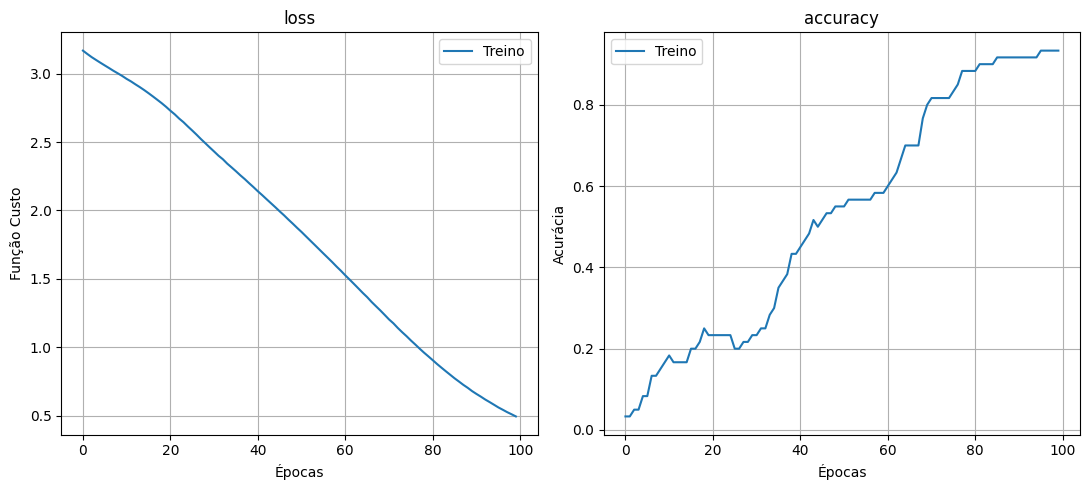

In [55]:
plot_acc_loss(h)

In [64]:
# start sequence for text generation
generated_text = "star o"

for i in range(40):
	x = np.array([[char_to_index[char] for char in generated_text[-seq_length:]]])
	x_one_hot = tf.one_hot(x, len(chars))
	prediction = model.predict(x_one_hot, verbose='silent')
	next_index = np.argmax(prediction)
	next_char = index_to_char[next_index]
	generated_text += next_char

print("Generated Text:", generated_text)

Generated Text: star o Processamento de Linguagem Natural (NLP


In [66]:
x = np.array([[char_to_index[char] for char in generated_text[-seq_length:]]])
x

array([[4, 3, 5]])

In [72]:
x_one_hot = tf.one_hot(x, len(chars))
x_one_hot

<tf.Tensor: shape=(3, 23), dtype=float32, numpy=
array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.]], dtype=float32)>

In [73]:
prediction = model.predict(x_one_hot, verbose='silent')
prediction

array([[2.0225891e-03, 5.2802130e-03, 6.0966563e-01, 3.7364964e-03,
        1.0650278e-02, 9.1661315e-04, 4.4282939e-04, 5.1899545e-02,
        2.3379775e-03, 5.3132055e-03, 1.0935624e-02, 2.6391058e-03,
        6.3871783e-03, 1.6625419e-03, 4.1686827e-03, 7.4658871e-02,
        1.1046363e-02, 8.0557290e-04, 1.6158159e-01, 9.6008908e-03,
        6.7804410e-04, 2.3365365e-02, 2.0479504e-04]], dtype=float32)

In [74]:
next_index = np.argmax(prediction)
next_index

np.int64(2)

In [75]:
next_char = index_to_char[next_index]
next_char

')'

#Exercícios
1. Aumentar o número de épocas de treinamento até que a função custo se estabilize
1. Verificar se as predições são acertivas
1. Modificar o texto de treinamento para: "Uma rede neural recorrente (RNN) é um tipo de rede neural artificial que usa dados sequenciais ou de séries temporais e pode ser utilizada para predições futuras"
1. Treinar a rede e verificar a eficiência das predições
1. Modificar o número de unidades da camada SimpleRNN: *units* = 10, 30, 60 e 100. Verificar e comparar os resultados
1. Alterar a quantidade de dados dos lotes de treinamento: *seq_length* = 5, 7 e 10.  Verificar e comparar os resultados
1. Inserir mais uma camada oculta SimpleRNN com o mesmo número de unidades da primeira camada, que deve ter o parâmetro `return_sequences=True`. Verificar e comparar os resultados

##Referências
[1] https://www.geeksforgeeks.org/introduction-to-recurrent-neural-network/

[2] https://machinelearningmastery.com/understanding-simple-recurrent-neural-networks-in-keras/

[3] https://www.tensorflow.org/guide/keras/working_with_rnns

[4] https://www.simplilearn.com/tutorials/deep-learning-tutorial/rnn

[5] https://www.datacamp.com/tutorial/tutorial-for-recurrent-neural-network

[6] https://github.com/bilkosem/simple-rnn_from_scratch